In [157]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [159]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [161]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [173]:
cols=df.columns
cols
#df=df.drop(['customerID'],axis=1)


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [175]:
num_cols=df.select_dtypes(include=np.number).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [177]:
cat_cols=df.select_dtypes(include=object).columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [179]:
df.shape

(7043, 20)

In [180]:
df['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [183]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [184]:
print(df['TotalCharges'].dtype)
cat_cols=df.select_dtypes(include=object).columns

float64


In [185]:
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)

In [186]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,True,False,False,True,True


In [187]:
df.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [189]:
X=df.drop('Churn_Yes',axis=1)
y=df['Churn_Yes']

In [194]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [195]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [196]:
y_pred=model.predict(X_test)

In [198]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.709013484740951

Confusion Matrix
[[824 212]
 [198 175]]

Classification Report
              precision    recall  f1-score   support

       False       0.81      0.80      0.80      1036
        True       0.45      0.47      0.46       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



In [199]:
print('Train_Score',model.score(X_train,y_train))
print('Test_Score',model.score(X_test,y_test))

Train_Score 0.9985800496982605
Test_Score 0.709013484740951


In [200]:
model=DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [201]:
y_pred=model.predict(X_test)

In [202]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8062455642299503

Confusion Matrix
[[964  72]
 [201 172]]

Classification Report
              precision    recall  f1-score   support

       False       0.83      0.93      0.88      1036
        True       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [203]:
print('Train_Score',model.score(X_train,y_train))
print('Test_Score',model.score(X_test,y_test))

Train_Score 0.7969471068512602
Test_Score 0.8062455642299503


In [204]:
for depth in [3,5,7,10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    print(
        depth,
        model.score(X_train,y_train),
        model.score(X_test,y_test)
    )

3 0.787362442314519 0.8019872249822569
5 0.7969471068512602 0.8062455642299503
7 0.8175363862264821 0.7913413768630234
10 0.8722044728434505 0.7650816181689141


In [205]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_})
importance.sort_values(by='Importance',ascending=False)
importance.head(10)

,Feature,Importance
0,SeniorCitizen,0.015462
1,tenure,0.288274
2,MonthlyCharges,0.155816
3,TotalCharges,0.132057
4,gender_Male,0.005647
5,Partner_Yes,0.011293
6,Dependents_Yes,0.018334
7,PhoneService_Yes,0.003068
8,MultipleLines_No phone service,0.004412
9,MultipleLines_Yes,0.018357


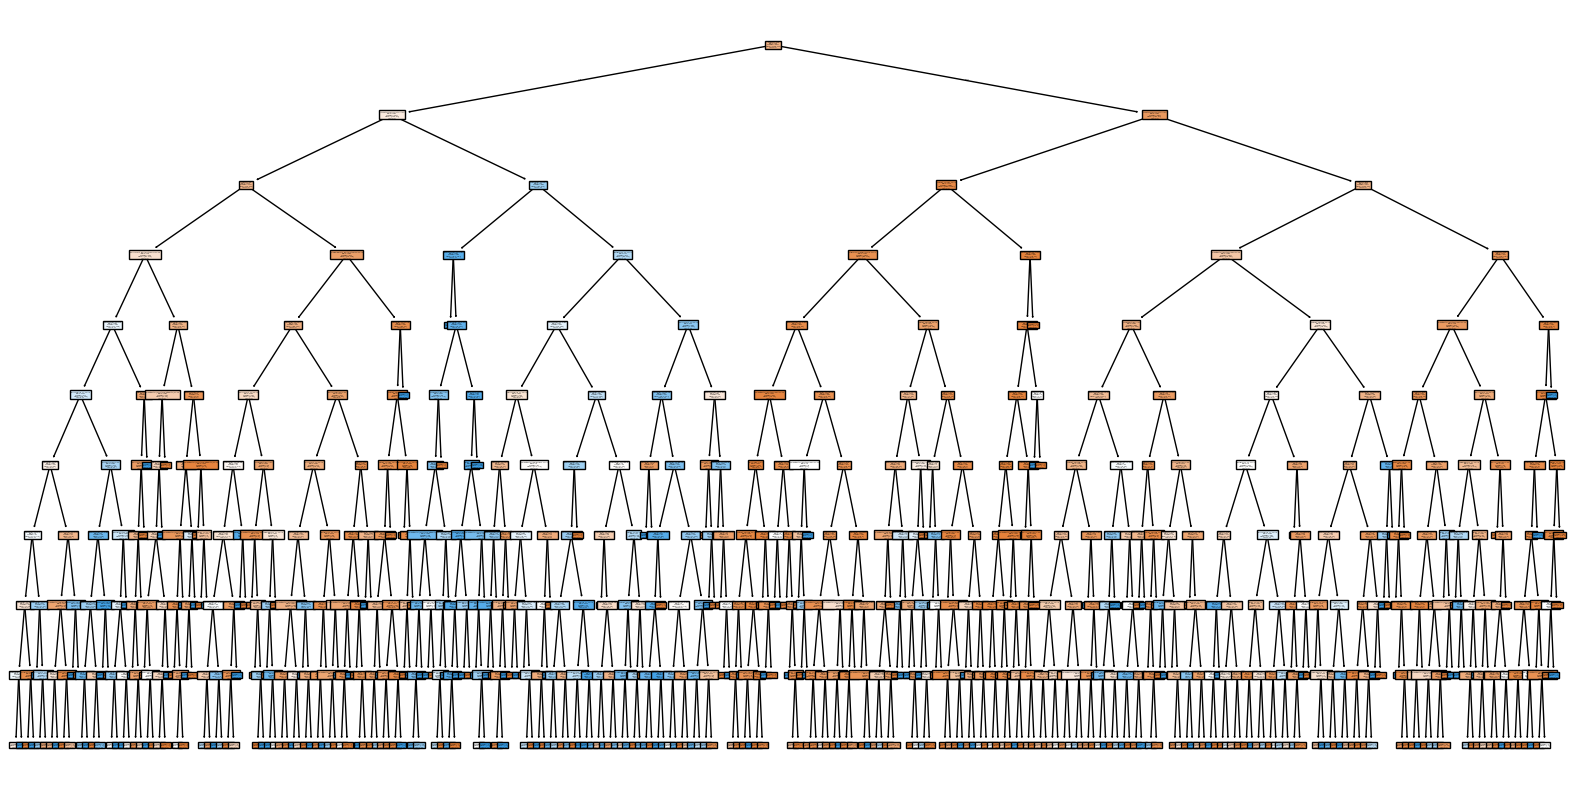

In [206]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

In [239]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [241]:
y_pred=rf.predict(X_test)


In [243]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.78708303761533

Confusion Matrix
[[820 216]
 [ 84 289]]

Classification Report
              precision    recall  f1-score   support

       False       0.91      0.79      0.85      1036
        True       0.57      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.80      1409



In [245]:
importance=pd.DataFrame({'Features':X.columns,'Importance':model.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
importance.head(10)

,Features,Importance
1,tenure,0.288274
10,InternetService_Fiber optic,0.184783
2,MonthlyCharges,0.155816
3,TotalCharges,0.132057
28,PaymentMethod_Electronic check,0.023217
9,MultipleLines_Yes,0.018357
6,Dependents_Yes,0.018334
24,Contract_One year,0.016340
19,TechSupport_Yes,0.016166
0,SeniorCitizen,0.015462


In [247]:
print("Train:", rf.score(X_train,y_train))
print("Test :", rf.score(X_test,y_test))


Train: 0.8358182463613774
Test : 0.78708303761533


In [315]:
from sklearn.ensemble import GradientBoostingClassifier
X_train['TotalCharges']=X_train['TotalCharges'].fillna(df['TotalCharges'].median())
X_test['TotalCharges']=X_test['TotalCharges'].fillna(df['TotalCharges'].median())
X_train.isnull().sum()
X['TotalCharges']=X['TotalCharges'].fillna(df['TotalCharges'].median())

In [317]:
gb=GradientBoostingClassifier(n_estimators=100,
                             learning_rate=0.1,
                             max_depth=5,random_state=42)
gb.fit(X_train,y_train)

GradientBoostingClassifier(max_depth=5, random_state=42)

In [319]:
y_pred=gb.predict(X_test)

In [321]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8069552874378992

Confusion Matrix
[[939  97]
 [175 198]]

Classification Report
              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1036
        True       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [323]:
print("Train:", gb.score(X_train,y_train))
print("Test :", gb.score(X_test,y_test))

Train: 0.8668796592119276
Test : 0.8069552874378992


In [325]:
for lr in [0.01, 0.05, 0.1, 0.2]:
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    gb.fit(X_train, y_train)

    print(
        lr,
        gb.score(X_train, y_train),
        gb.score(X_test, y_test)
    )

0.01 0.7807951721689741 0.7856635911994322
0.05 0.8125665601703941 0.8126330731014905
0.1 0.8242811501597445 0.8090844570617459
0.2 0.8441604543840966 0.8097941802696949


In [326]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    gb,
    X,
    y,
    cv=5
)
print(scores)

[0.80411639 0.80482612 0.77501774 0.80681818 0.80255682]


In [329]:
print(scores.std())

0.01190370057744046


In [249]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [251]:
from xgboost import XGBClassifier

In [255]:
xgb=XGBClassifier(n_estimators=100,
                 max_depth=4,
                 learning_rate=0.1,
                 random_state=42)

In [257]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [259]:
y_pred=xgb.predict(X_test)

In [261]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8112136266855926

Confusion Matrix
[[939  97]
 [169 204]]

Classification Report
              precision    recall  f1-score   support

       False       0.85      0.91      0.88      1036
        True       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [265]:
print("Train:", xgb.score(X_train,y_train))
print("Test :", xgb.score(X_test,y_test))

Train: 0.8269435569755058
Test : 0.8112136266855926


In [331]:
from sklearn.model_selection import GridSearchCV
gb=GradientBoostingClassifier(random_state=42)
grid_params={'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.2],'max_depth':[3,4,5]}
grid=GridSearchCV(
    estimator=gb,
    param_grid=grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
0.8015610692496938
